<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/blob/main/Week03/doc/Ejercicio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, r2_score

# Implementación de código

In [3]:
# Carga el conjunto de datos Breast Cancer

dataset = load_breast_cancer()
X = dataset.data # 569x30
y = dataset.target # 569x1

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = MinMaxScaler(feature_range=(0,1)) #[0,1]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crea y eentrena el modelo de regresión lógistica
model = DecisionTreeClassifier(max_depth=4, criterion = 'gini')
model.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred_binary = (y_pred > 0.5).astype(int)



# Presentacion de los datos

In [4]:
# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# Correlación

In [7]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:", cm)

Matriz de Confusión: [[40  3]
 [ 3 68]]


Text(0.5, 1.0, 'Matriz de Confusión')

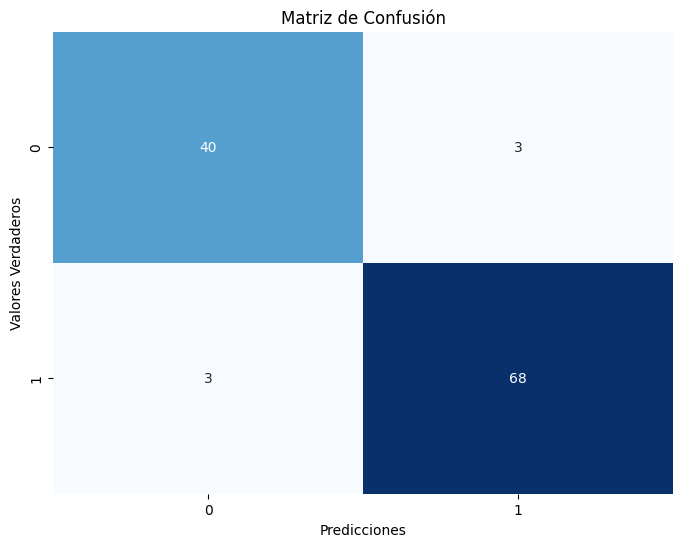

In [8]:
# Gráfico de la CM

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')

# Métricas

In [9]:
# Exactitud

accuracy_score = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy_score)

Exactitud: 0.9473684210526315


In [10]:
# Sensibilidad

recall = recall_score(y_test, y_pred)
print("Sensibilidad:", recall)

Sensibilidad: 0.9577464788732394


In [11]:
# Precisión

precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

Precisión: 0.9577464788732394


In [12]:
# Especificidad

specifity = recall_score(y_test, y_pred, pos_label=0)
print("Especificidad:", specifity)

Especificidad: 0.9302325581395349


In [13]:
# Puntuacion F1

f1 = f1_score(y_test, y_pred)
print("Puntuación F1:", f1)

Puntuación F1: 0.9577464788732394


In [14]:
# Area bajo la curva

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

AUC: 0.9439895185063871


In [16]:
# R Score (R2 coefficient of determination)

R = r2_score(y_test, y_pred)
print("R2:", R)

R2: 0.7759580740255486


# Gráfico de ROC

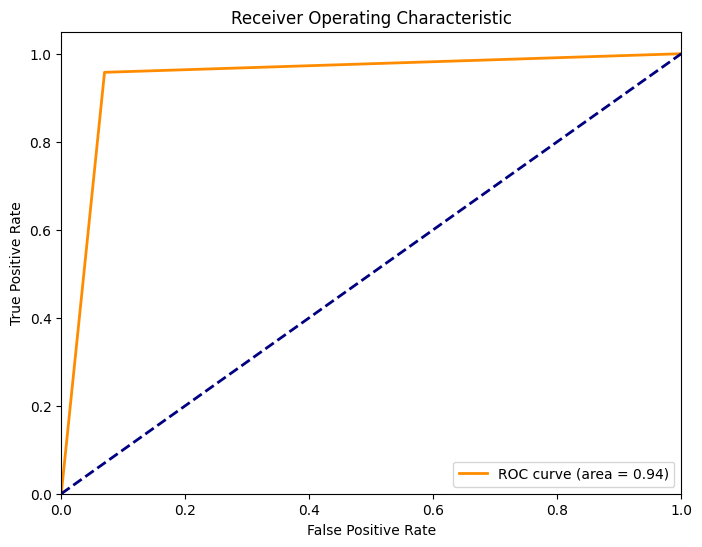

In [15]:
# Gráfico

plt.figure(figsize=(8, 6))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()